# IMPORT LIBRARIES

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
from numba import njit
import math
import xarray as xr
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize

##USE DATA FROM PYTHON

In [ ]:
!pip install aqua-fetch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.1/289.1 kB 14.6 MB/s eta 0:00:00


In [ ]:
!pip install aqua-fetch netCDF4 xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.7 MB/s eta 0:00:00


In [ ]:

from aqua_fetch import RainfallRunoff

#
rr = RainfallRunoff("CAMELS_US")

downloading camels_attributes_v2.0.pdf from https://zenodo.org/records/15529996/files/
0% of 0.09 MB downloaded
100% of 0.09 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_attributes_v2.0.xlsx from https://zenodo.org/records/15529996/files/
0% of 0.02 MB downloaded
100% of 0.02 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_clim.txt from https://zenodo.org/records/15529996/files/
0% of 0.1 MB downloaded
100% of 0.1 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_geol.txt from https://zenodo.org/records/15529996/files/
0% of 0.07 MB downloaded
100% of 0.07 MB downloaded
unzipping files in /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_US
downloading camels_hydro.txt from https://zenodo.org/records/15529996/files/
0% of 0.12 MB download

In [ ]:
meta, ds = rr.fetch()

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 3. Use the EXACT variable names from your dataset
dynamic_features_to_keep = [
    "solrad_wm2",
    "airtemp_C_max",
    "airtemp_C_min",
    "dayl(s)",
    "vp_hpa",
    "pcp_mm",
    "q_cms_obs"
]

# 4. Subset the dataset
print("Extracting dynamic features...")
ds_optimized = ds.sel(dynamic_features=dynamic_features_to_keep)

# 5. Save the ultra-lightweight dataset to your Google Drive
save_path = '/content/drive/MyDrive/CAMELS_US_QC_Filtered.nc'
#ds_optimized.to_netcdf(save_path)

print(f"✅ Success! Optimized dataset saved to {save_path}")

Extracting dynamic features...
✅ Success! Optimized dataset saved to /content/drive/MyDrive/CAMELS_US_QC_Filtered.nc


In [ ]:

# Loads instantly!
ds = xr.open_dataset('/content/drive/MyDrive/CAMELS_US_QC_Filtered.nc')

In [ ]:
print(ds.head())

<xarray.Dataset> Size: 134kB
Dimensions:           (time: 5, dynamic_features: 5)
Coordinates:
  * time              (time) datetime64[ns] 40B 1980-01-01 ... 1980-01-05
  * dynamic_features  (dynamic_features) <U13 260B 'solrad_wm2' ... 'vp_hpa'
Data variables: (12/671)
    12035000          (time, dynamic_features) float64 200B ...
    14236200          (time, dynamic_features) float64 200B ...
    14308990          (time, dynamic_features) float64 200B ...
    14362250          (time, dynamic_features) float64 200B ...
    12144000          (time, dynamic_features) float64 200B ...
    14325000          (time, dynamic_features) float64 200B ...
    ...                ...
    08086290          (time, dynamic_features) float64 200B ...
    08175000          (time, dynamic_features) float64 200B ...
    08103900          (time, dynamic_features) float64 200B ...
    08082700          (time, dynamic_features) float64 200B ...
    08158810          (time, dynamic_features) float64 200B ..

In [ ]:
print(ds.dynamic_features.values)

['solrad_wm2' 'airtemp_C_max' 'airtemp_C_min' 'dayl(s)' 'vp_hpa' 'pcp_mm'
 'q_cms_obs']


In [ ]:
# Full period
print(ds["time"].values[0], ds["time"].values[-1])

1980-01-01T00:00:00.000000000 2014-12-31T00:00:00.000000000


###General

In [ ]:
import xarray as xr
import numpy as np

# --- 1. Extract valid station keys (assuming valid IDs have length 8) ---
station_keys = [k for k in ds.data_vars if len(k) == 8]

# --- 2. Convert dataset to a DataArray with a "station_id" dimension ---
ds_stations = ds[station_keys].to_array(dim="station_id")  # "station_id" contains all station names

# --- 3. Extract observed discharge (in m³/s) ---
q_obs = ds_stations.sel(dynamic_features="q_cms_obs").drop_vars("dynamic_features").squeeze()
# Now q_obs.dims = ('station_id', 'time')

# --- 4. Retrieve basin areas (in km²) ---
attrs = rr.fetch_static_features()
station_ids = q_obs.coords["station_id"].values

area = xr.DataArray(
    [attrs["area_km2"].get(sid, np.nan) for sid in station_ids],
    coords={"station_id": station_ids},
    dims=["station_id"]
)

# --- 5. Convert discharge from m³/s to mm/day ---
# Formula: (Q [m³/s] * 86.4) / Area [km²]
# Note: 86.4 converts m³/s over km² into mm/day
q_mm_per_day = (q_obs.where(q_obs >= 0) * 86.4) / area

# --- 6. Display result ---
print(q_mm_per_day)

<xarray.DataArray (station_id: 671, time: 12784)> Size: 69MB
array([[15.6028915 , 15.2215581 , 13.85511343, ...,  8.48466808,
         7.69022351,  7.08644563],
       [ 5.06949084,  5.78789462,  6.43852446, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,  2.84383313,
         2.33340155,  1.86672124],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,         nan,
                nan,         nan],
       [ 0.03463219,  0.03463219,  0.03078417, ...,         nan,
                nan,         nan],
       [ 0.0471291 ,  0.03713202,  0.02070824, ...,  0.02927717,
         0.02927717,  0.0249927 ]])
Coordinates:
  * station_id  (station_id) object 5kB '12035000' '14236200' ... '08104900'
  * time        (time) datetime64[ns] 102kB 1980-01-01 1980-01-02 ... 2014-12-31


**Functions**

In [ ]:
# ==========================================================
# 1. COMPILED MATH FUNCTION (FAO-56 Rigorous Net Radiation)
# ==========================================================
@njit(cache=True)
def compute_pt_pet(solrad, tmax, tmin, dayl, vp_pa, yday, lat_deg, elevation, alpha):
    """Calculates Priestley-Taylor PET strictly following Allen et al. (1998)."""
    N = len(solrad)
    PET = np.empty(N, dtype=np.float64)

    # Constants
    gamma = 0.066      # psychrometric constant (kPa C-1)
    lambda_v = 2.45    # latent heat of vaporization (MJ kg-1)
    albedo = 0.23      # standard reference albedo
    sigma = 4.903e-9   # Stefan-Boltzmann constant (MJ K-4 m-2 day-1)
    Gsc = 0.0820       # Solar constant (MJ m-2 min-1)

    # Latitude in radians
    lat_rad = lat_deg * np.pi / 180.0

    for i in range(N):
        T_mean = (tmax[i] + tmin[i]) * 0.5

        # --- 1. Vapor Pressures ---
        es_max = 0.6108 * np.exp((17.27 * tmax[i]) / (tmax[i] + 237.3))
        es_min = 0.6108 * np.exp((17.27 * tmin[i]) / (tmin[i] + 237.3))
        es = (es_max + es_min) * 0.5

        ea = vp_pa[i] / 10.0  # Convert Daymet Pa to kPa

        # --- 2. Radiation Balance (Rn) ---
        # Measured incoming shortwave (Rs) in MJ m-2 day-1
        Rs = solrad[i] * dayl[i] * 1e-6

        # Net shortwave (Rns)
        Rns = (1.0 - albedo) * Rs

        # Extraterrestrial Radiation (Ra) based on Julian Day (yday)
        J = yday[i]
        dr = 1.0 + 0.033 * np.cos(2.0 * np.pi * J / 365.0)
        delta = 0.409 * np.sin((2.0 * np.pi * J / 365.0) - 1.39)

        # Sunset hour angle (ws) with failsafe for high latitudes
        tan_lat_delta = np.tan(lat_rad) * np.tan(delta)
        if tan_lat_delta < -1.0:
            ws = 0.0
        elif tan_lat_delta > 1.0:
            ws = np.pi
        else:
            ws = np.arccos(-tan_lat_delta)

        Ra = (24.0 * 60.0 / np.pi) * Gsc * dr * (
            ws * np.sin(lat_rad) * np.sin(delta) +
            np.cos(lat_rad) * np.cos(delta) * np.sin(ws)
        )

        # Clear-sky solar radiation (Rso) adjusted for elevation
        Rso = (0.75 + 2e-5 * elevation) * Ra
        if Rso <= 0.0:
            Rso = 0.001 # Failsafe to prevent division by zero in winter

        # Cloudiness factor (f_cloud)
        Rs_Rso_ratio = Rs / Rso
        if Rs_Rso_ratio < 0.3: Rs_Rso_ratio = 0.3 # Bound per FAO-56
        if Rs_Rso_ratio > 1.0: Rs_Rso_ratio = 1.0
        f_cloud = 1.35 * Rs_Rso_ratio - 0.35

        # Net Longwave (Rnl)
        Tmax_K4 = (tmax[i] + 273.16)**4
        Tmin_K4 = (tmin[i] + 273.16)**4
        Rnl = sigma * ((Tmax_K4 + Tmin_K4) * 0.5) * (0.34 - 0.14 * np.sqrt(ea)) * f_cloud

        # Final Net Radiation (Rn)
        Rn = Rns - Rnl

        # --- 3. Priestley-Taylor PET ---
        # Slope of saturation vapor pressure curve at T_mean
        es_mean = 0.6108 * np.exp((17.27 * T_mean) / (T_mean + 237.3))
        s = 4098.0 * es_mean / ((T_mean + 237.3)**2)

        # Final calculation where Soil Heat Flux (G) = 0
        PET[i] = alpha * (s / (s + gamma)) * (Rn / lambda_v)

        # Failsafe for deep winter
        if PET[i] < 0.0:
            PET[i] = 0.0

    return PET

# ==========================================================
# 2. XARRAY DATA EXTRACTOR
# ==========================================================
def priestley_taylor_pet(ds_recent, station_id, alpha):
    """
    Extracts dynamic forcing and static basin data to call the compiled PET function.
    Requires alpha to be passed dynamically from your basin calibration loop.
    """
    station_data = ds_recent[station_id]

    # Dynamic Daymet Variables
    solrad = station_data.sel(dynamic_features="solrad_wm2").to_numpy()
    tmax = station_data.sel(dynamic_features="airtemp_C_max").to_numpy()
    tmin = station_data.sel(dynamic_features="airtemp_C_min").to_numpy()
    dayl = station_data.sel(dynamic_features="dayl(s)").to_numpy()
    vp_pa = station_data.sel(dynamic_features="vp_hpa").to_numpy()

    # Julian Day (Day of year 1-365) from the time index
    yday = station_data.time.dt.dayofyear.to_numpy()

    # Static Basin Variables (Update these accessors if your xarray metadata differs)
    # This assumes lat and elevation are stored as attributes or coordinates
    try:
        lat_deg = float(station_data.coords['lat'].values)
        elevation = float(station_data.coords['elevation'].values)
    except KeyError:
        # Fallback if they are stored in the dataset attributes instead
        lat_deg = float(station_data.attrs.get('latitude', 0.0))
        elevation = float(station_data.attrs.get('elevation', 0.0))

    # Execute the Numba-optimized math function
    return compute_pt_pet(solrad, tmax, tmin, dayl, vp_pa, yday, lat_deg, elevation, alpha)

## **Main Code** HBV

In [ ]:
# ============================================
# Metrics definitions
# ============================================

def NSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.var(obs) == 0:
        return np.nan
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)


def NNSE(nse):
    if np.isnan(nse):
        return np.nan
    return 1.0 / (2.0 - nse)


def RMSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    return np.sqrt(np.mean((sim - obs)**2))


def PBIAS(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.sum(obs) == 0:
        return np.nan
    return  np.sum(sim - obs) / np.sum(obs)


def FHV(obs, sim, top_fraction=0.02):
    epsilon = 0
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_top = int(len(obs) * top_fraction)
    if n_top == 0:
        return np.nan
    idx = np.argsort(obs)[-n_top:]
    obs_top = obs[idx]
    sim_top = sim[idx]
    return  np.sum(sim_top - obs_top) / (np.sum(obs_top) + epsilon)


def FLV(obs, sim, bottom_fraction=0.3):
    epsilon = 1e-6
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_bot = int(len(obs) * bottom_fraction)
    if n_bot == 0:
        return np.nan
    idx = np.argsort(obs)[:n_bot]
    obs_bot = obs[idx]
    sim_bot = sim[idx]
    return np.sum(sim_bot - obs_bot) / (np.sum(obs_bot) + epsilon)

In [ ]:
@njit
def hbv_numba(P, ET, params):
    FC, BETA, LP, K0, K1, K2, UZL, PERC  = params

    SM = 0.5 * FC
    UZ = 0.0
    LZ = 0.0

    n = len(P)
    Qsim = np.zeros(n)

    for t in range(n):
        p = P[t]
        et = ET[t]

        # Soil moisture
        soil_ratio = SM / FC
        recharge = p * soil_ratio**BETA
        SM += p - recharge
        if SM > FC:
            recharge += SM - FC
            SM = FC
        evap = min(et * min(SM / (LP * FC), 1.0), SM)
        SM -= evap

        # Upper reservoir
        UZ += recharge
        perc = min(PERC, UZ)
        UZ -= perc
        LZ += perc

        # Quick flow
        Q0 = K0 * (UZ - UZL) if UZ > UZL else 0.0
        if Q0 > 0:
            UZ -= Q0

        # Interflow
        Q1 = K1 * UZ
        UZ -= Q1

        # Baseflow
        Q2 = K2 * LZ
        LZ -= Q2

        # Total discharge
        Qsim[t] = max(0.0, Q0 + Q1 + Q2)

    return Qsim

In [ ]:
b1_ratio = 0.7
max_missing_ratio = 1
results_HBV = {}

stations_to_skip = [""]
stations = [s for s in q_mm_per_day.station_id.values if s not in stations_to_skip]

start_date = "1981-01-01"
end_date = "2013-12-31"

q_mm_per_day_recent = q_mm_per_day.sel(time=slice(start_date, end_date))
ds_recent = ds.sel(time=slice(start_date, end_date)).load()

for i, station_id in enumerate(stations, 1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    # Débits observés et forcing
    Q_obs = q_mm_per_day_recent.sel(station_id=station_id).to_numpy()
    P = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    PET = priestley_taylor_pet(ds_recent, station_id, alpha=1.0)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Pas de données")
        continue

    missing_count = np.sum(np.isnan(Q_obs))
    missing_ratio = missing_count / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Trop de valeurs manquantes ({missing_ratio*100:.1f}%)")
        continue

    # Split calibration / validation
    b1 = int(N * b1_ratio)
    Q_train = Q_obs[:b1]
    Q_val = Q_obs[b1:]
    P_train = P[:b1]
    PET_train = PET[:b1]

    # Function objective HBV
    def objective_hbv(params, P_train, PET_train, Q_obs_train):
        alpha = params[-1]
        Q_sim = hbv_numba(P_train, alpha * PET_train, params[:-1])
        nse = NSE(Q_obs_train, Q_sim)
        return 1 - nse if np.isfinite(nse) else 1e6

    # Multi-start optimisation
    bounds = [
        (10,2000), (0.1,20), (0.01,5), (0,5), (0,3),
        (0,2), (0,500), (0,20), (0,10), (None,None)
    ]
    initial_guesses = [
        [100,2,0.5,0.1,0.05,0.01,50,2,0.5,1.0],
        [300,4,0.7,0.2,0.1,0.05,30,1,0.8,1.2],
        [500,3,0.9,0.3,0.05,0.03,80,3,0.2,1.5],
        [1000,3,0.9,0.5,0.1,0.03,80,3,0.02,5],
        [200,10,2,3,0.05,0.03,300,3,0.2,4]
    ]

    best_res = None
    best_val = float("inf")
    for guess in initial_guesses:
        try:
            res = minimize(
                objective_hbv,
                guess,
                args=(P_train, PET_train, Q_train),
                method="L-BFGS-B",
                bounds=bounds,
                options={'maxiter':3000, 'disp':False}
            )
            if res.fun < best_val:
                best_val = res.fun
                best_res = res
        except Exception as e:
            print(f"⚠️ Optimisation échouée pour {guess}: {e}")
            continue

    if best_res is None:
        print("⚠️ Aucune optimisation réussie")
        continue

    # Optimized parameters
    params_best = best_res.x
    alpha_best = params_best[-1]

    # Simulation completed
    Qsim = hbv_numba(P, alpha_best * PET, params_best[:-1])
    Qsim_cal = Qsim[:b1]
    Qsim_val = Qsim[b1:]

    # --- 6 metrics ---
    NSE_cal = NSE(Q_train, Qsim_cal)
    NSE_val = NSE(Q_val, Qsim_val)
    NNSE_cal = NNSE(NSE_cal)
    NNSE_val = NNSE(NSE_val)
    RMSE_cal = RMSE(Q_train, Qsim_cal)
    RMSE_val = RMSE(Q_val, Qsim_val)
    PBIAS_cal = PBIAS(Q_train, Qsim_cal)
    PBIAS_val = PBIAS(Q_val, Qsim_val)
    FHV_cal = FHV(Q_train, Qsim_cal)
    FHV_val = FHV(Q_val, Qsim_val)
    FLV_cal = FLV(Q_train, Qsim_cal)
    FLV_val = FLV(Q_val, Qsim_val)

    # --- Save ---
    results_HBV[station_id] = {
        "params": params_best,
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "NNSE_cal": NNSE_cal,
        "NNSE_val": NNSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,
        "PBIAS_cal": PBIAS_cal,
        "PBIAS_val": PBIAS_val,
        "FHV_cal": FHV_cal,
        "FHV_val": FHV_val,
        "FLV_cal": FLV_cal,
        "FLV_val": FLV_val,
        "Qsim": Qsim,
        "Q_obs": Q_obs,
        "missing_ratio": missing_ratio,
        "missing_count": missing_count
    }


    # --- Displaying ---
    print(f"✅ Station {station_id} metrics:")
    print(f"   Cal -> NSE: {NSE_cal:.3f}, NNSE: {NNSE_cal:.3f}, RMSE: {RMSE_cal:.3f}, PBIAS: {PBIAS_cal:.3f}, FHV: {FHV_cal:.3f}, FLV: {FLV_cal:.3f}")
    print(f"   Val -> NSE: {NSE_val:.3f}, NNSE: {NNSE_val:.3f}, RMSE: {RMSE_val:.3f}, PBIAS: {PBIAS_val:.3f}, FHV: {FHV_val:.3f}, FLV: {FLV_val:.3f}")


print(f"\n✅ Simulation complète pour {len(results_HBV)} bassins")


=== Station 12035000 (1/671) ===


/tmp/ipykernel_281/2951693871.py:64: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


✅ Station 12035000 metrics:
   Cal -> NSE: 0.886, NNSE: 0.897, RMSE: 3.163, PBIAS: -0.039, FHV: -0.214, FLV: -0.255
   Val -> NSE: 0.869, NNSE: 0.884, RMSE: 3.045, PBIAS: -0.118, FHV: -0.256, FLV: -0.381

=== Station 14236200 (2/671) ===
✅ Station 14236200 metrics:
   Cal -> NSE: 0.787, NNSE: 0.825, RMSE: 3.317, PBIAS: -0.090, FHV: -0.295, FLV: 0.060
   Val -> NSE: 0.759, NNSE: 0.806, RMSE: 3.422, PBIAS: -0.098, FHV: -0.273, FLV: 0.107

=== Station 14308990 (3/671) ===
✅ Station 14308990 metrics:
   Cal -> NSE: 0.810, NNSE: 0.841, RMSE: 1.123, PBIAS: 0.075, FHV: -0.175, FLV: 0.012
   Val -> NSE: 0.720, NNSE: 0.781, RMSE: 1.060, PBIAS: 0.087, FHV: -0.054, FLV: 0.119

=== Station 14362250 (4/671) ===
✅ Station 14362250 metrics:
   Cal -> NSE: 0.810, NNSE: 0.840, RMSE: 0.380, PBIAS: 0.056, FHV: -0.201, FLV: 0.213
   Val -> NSE: 0.699, NNSE: 0.769, RMSE: 0.335, PBIAS: 0.252, FHV: -0.088, FLV: 0.396

=== Station 12144000 (5/671) ===
✅ Station 12144000 metrics:
   Cal -> NSE: 0.675, NNSE: 0.

/tmp/ipykernel_281/2109650594.py:11: RuntimeWarning: overflow encountered in square
  return 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)


✅ Station 06784000 metrics:
   Cal -> NSE: 0.229, NNSE: 0.565, RMSE: 0.086, PBIAS: -0.041, FHV: -0.495, FLV: 0.669
   Val -> NSE: -0.872, NNSE: 0.348, RMSE: 0.125, PBIAS: 0.477, FHV: 0.191, FLV: 1.300

=== Station 06479438 (433/671) ===
✅ Station 06479438 metrics:
   Cal -> NSE: 0.156, NNSE: 0.542, RMSE: 0.468, PBIAS: 0.003, FHV: -0.768, FLV: 32.347
   Val -> NSE: 0.068, NNSE: 0.518, RMSE: 0.372, PBIAS: 0.392, FHV: -0.773, FLV: 20.989

=== Station 06814000 (434/671) ===
✅ Station 06814000 metrics:
   Cal -> NSE: 0.716, NNSE: 0.779, RMSE: 1.003, PBIAS: 0.422, FHV: -0.252, FLV: 7.472
   Val -> NSE: 0.641, NNSE: 0.736, RMSE: 0.803, PBIAS: 0.720, FHV: -0.245, FLV: 15.250

=== Station 06278300 (435/671) ===
✅ Station 06278300 metrics:
   Cal -> NSE: 0.193, NNSE: 0.553, RMSE: 2.738, PBIAS: 0.016, FHV: -0.836, FLV: 4.460
   Val -> NSE: 0.251, NNSE: 0.572, RMSE: 2.783, PBIAS: 0.154, FHV: -0.791, FLV: 3.446

=== Station 06191500 (436/671) ===
✅ Station 06191500 metrics:
   Cal -> NSE: 0.254, NN

In [ ]:
# =============================================================
# 📌 FUNCTION TO PRINT METRIC SUMMARY
# =============================================================
def summarize_metric(metric_name, results_dict):

    values = [res.get(metric_name, np.nan) for res in results_dict.values()]
    values = np.array(values)
    values = values[~np.isnan(values)]  # remove NaN

    if len(values) == 0:
        print(f"{metric_name}: No valid values\n")
        return

    print(f"{metric_name}")
    print(f"Median : {np.percentile(values,50):.3f}")
    print(f"Mean   : {np.mean(values):.3f}")
    print(f"Min    : {np.min(values):.3f}")
    print(f"Max    : {np.max(values):.3f}")
    print(f"5th–95th percentile : {np.percentile(values,5):.3f} – {np.percentile(values,95):.3f}")
    print("-"*40)


# =============================================================
# 📌 CALIBRATION SUMMARY
# =============================================================
print("\n================= CALIBRATION SUMMARY =================\n")

metrics_cal = [
    "NSE_cal",
    "NNSE_cal",
    "RMSE_cal",
    "PBIAS_cal",
    "FHV_cal",
    "FLV_cal"
]

for metric in metrics_cal:
    summarize_metric(metric, results_HBV)


# =============================================================
# 📌 VALIDATION SUMMARY
# =============================================================
print("\n================= VALIDATION SUMMARY =================\n")

metrics_val = [
    "NSE_val",
    "NNSE_val",
    "RMSE_val",
    "PBIAS_val",
    "FHV_val",
    "FLV_val"
]

for metric in metrics_val:
    summarize_metric(metric, results_HBV)


================= CALIBRATION SUMMARY =================

NSE_cal
Median : 0.619
Mean   : 0.566
Min    : 0.021
Max    : 0.916
5th–95th percentile : 0.149 – 0.824
----------------------------------------
NNSE_cal
Median : 0.724
Mean   : 0.711
Min    : 0.505
Max    : 0.923
5th–95th percentile : 0.540 – 0.850
----------------------------------------
RMSE_cal
Median : 1.372
Mean   : 1.554
Min    : 0.039
Max    : 9.137
5th–95th percentile : 0.203 – 3.787
----------------------------------------
PBIAS_cal
Median : 0.009
Mean   : 0.024
Min    : -0.769
Max    : 0.647
5th–95th percentile : -0.166 – 0.267
----------------------------------------
FHV_cal
Median : -0.354
Mean   : -0.408
Min    : -0.899
Max    : -0.074
5th–95th percentile : -0.782 – -0.154
----------------------------------------
FLV_cal
Median : 1.411
Mean   : 4388079.045
Min    : -0.944
Max    : 471314901.176
5th–95th percentile : -0.012 – 401.622
----------------------------------------

================= VALIDATION SUMMARY ====

In [ ]:
# ============================================
# Create Excel file
# ============================================

records = []
for station_id, res in results_HBV.items():
    record = {
        "Station": station_id,
        "NSE_val": res["NSE_val"],
        "NNSE_val": res["NNSE_val"],
        "RMSE_val": res["RMSE_val"],
        "PBIAS_val": res["PBIAS_val"],
        "FHV_val": res["FHV_val"],
        "FLV_val": res["FLV_val"],
    }
    records.append(record)

df_val_metrics = pd.DataFrame(records)
excel_filename = "HBV_validation_metrics.xlsx"
df_val_metrics.to_excel(excel_filename, index=False)
print(f"✅ Excel saved: {excel_filename}")

#
try:
    from google.colab import files
    files.download(excel_filename)
except:
    print("⚠️ Not running in Colab. File saved locally.")

✅ Excel saved: HBV_validation_metrics.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

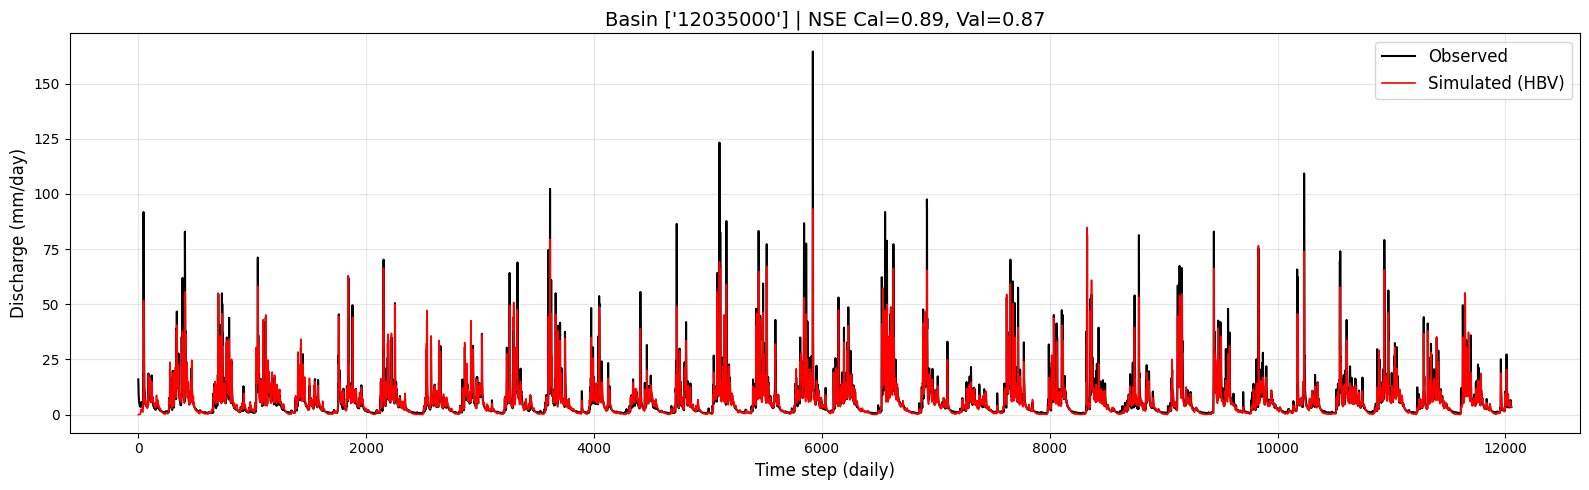

In [ ]:
import matplotlib.pyplot as plt

# ===============================
# Identify the bassin 569
# ===============================
stations = list(results_HBV.keys())
station_569 = ['12035000']

res = results_HBV['12035000']
Q_obs = res["Q_obs"]
Qsim = res["Qsim"]

# ===============================
# Plot Observed vs Simulated
# ===============================
plt.figure(figsize=(16,5))
plt.plot(Q_obs, label="Observed", color="black", linewidth=1.5)
plt.plot(Qsim, label="Simulated (HBV)", color="red", linewidth=1.2)

plt.title(f"Basin {station_569} | NSE Cal={res['NSE_cal']:.2f}, Val={res['NSE_val']:.2f}", fontsize=14)
plt.xlabel("Time step (daily)", fontsize=12)
plt.ylabel("Discharge (mm/day)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()